# Problem 1 - Real GDP across US states

**Question 1.1 - downloading and computing the data**


1.1.1) Downloading the data from FRED

In [ ]:
from data_loader import load_state_data

# a. FRED API key
api_key = '6c88ec46f20df2ad295843c1c220a79b'

# b. downloading real GDP and population for all the states by importing our data loading function.
df_gdp, df_pop = load_state_data(api_key)

# c. Controlling that the data has been correctly loaded from the API
print('Real GDP — millions of chained 2017 $ (first 5 rows):')
display(df_gdp.head())
print('Population — thousands of persons (first 5 rows):')
display(df_pop.head())

Real GDP — millions of chained 2017 $ (first 5 rows):


,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
1997,154700.0,41071.0,180293.9,87180.3,1441226.4,189445.6,205965.2,51267.0,603988.6,351183.9,...,27116.2,226832.8,860046.9,86283.5,21372.2,319992.6,281522.2,60364.6,222978.5,24257.7
1998,160396.4,40263.7,197492.1,89905.3,1538612.3,206449.1,212255.0,56487.0,634032.3,377705.9,...,28772.1,240963.4,920059.6,91312.7,22266.5,338931.5,299817.0,61725.7,232087.1,24804.7
1999,166531.8,39783.1,214293.9,94756.9,1655438.5,221040.8,218860.0,60866.2,664152.0,404465.2,...,30038.3,248457.5,957247.2,95206.8,23561.7,356391.8,322721.6,63691.7,242026.0,25866.8
2000,168695.3,38428.1,224729.3,95509.8,1784320.6,238739.3,233874.2,63388.8,693837.3,417713.5,...,32124.9,251030.2,989904.9,98648.5,24844.6,372914.1,325857.6,63364.6,248572.0,26614.2
2001,168448.3,40014.4,230885.6,95528.7,1784567.7,242650.1,236338.1,65724.8,714638.0,422731.6,...,32396.9,250311.4,1020517.0,100244.3,25681.8,386444.7,317860.6,63599.8,252941.8,28338.1


Population — thousands of persons (first 5 rows):


,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
1900,1830.0,NaN,124.0,1314.0,1490.0,543.0,910.0,185.0,530.0,2220.0,...,403.0,2023.0,3055.0,277.0,344.0,1858.0,523.0,959.0,2072.0,93.0
1901,1907.0,NaN,131.0,1341.0,1550.0,581.0,931.0,187.0,544.0,2263.0,...,418.0,2041.0,3132.0,284.0,347.0,1887.0,583.0,972.0,2109.0,100.0
1902,1935.0,NaN,138.0,1360.0,1623.0,621.0,952.0,188.0,565.0,2305.0,...,431.0,2060.0,3210.0,292.0,349.0,1894.0,651.0,1000.0,2141.0,105.0
1903,1957.0,NaN,144.0,1384.0,1702.0,652.0,972.0,190.0,587.0,2346.0,...,437.0,2082.0,3291.0,299.0,350.0,1890.0,719.0,1037.0,2171.0,108.0
1904,1978.0,NaN,151.0,1419.0,1792.0,659.0,987.0,192.0,599.0,2387.0,...,452.0,2086.0,3374.0,308.0,353.0,1889.0,782.0,1064.0,2202.0,111.0


1.1.2) Merging the data


After examining the data we expect the merged series to only contain data from 1997 to 2025 as these are the only years where both series contain data.

In [ ]:
from states import STATES

# a. We use an inner join on the year, such that we only keep observations in both series.
years = df_gdp.index.intersection(df_pop.index)
gdp = df_gdp.loc[years]
pop = df_pop.loc[years]

# b. We now drop missing observation in either series
complete = gdp.notna().all(axis=0) & pop.notna().all(axis=0)
gdp = gdp.loc[:, complete]
pop = pop.loc[:, complete]

# c. Printing what is kept and dropped
dropped = [s for s in STATES if s not in gdp.columns]
print(f'years:  {gdp.shape[0]}  ({years.min()}–{years.max()})')
print(f'states: {gdp.shape[1]}')
print(f'dropped states: {dropped if dropped else "none"}')

years:  29  (1997–2025)
states: 50
dropped states: none


1.1.3) Computing real gdp. pr person

In [10]:
# we multiply with 1000 such that we get the number in dollars pr. person
y = gdp / pop * 1_000   

# a. displaying our computations
print('Real GDP per person, $ (first 5 rows):')
display(y.tail())

Real GDP per person, $ (first 5 rows):


,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
2021,46326.418429,70466.518738,54503.203317,45467.137652,80482.169315,69880.200221,75054.722245,74821.664859,53701.127341,59644.782127,...,62496.053232,57656.343682,64434.908012,63262.715899,51888.640655,65333.746266,80849.257701,42684.306865,56926.438867,64145.312268
2022,47243.024636,68845.471806,56145.882024,45504.587638,80439.194571,72193.827301,77195.666850,79499.627063,55587.053246,61309.029320,...,60778.568255,58818.134519,65580.844307,64187.808345,53914.677570,66731.858563,82577.604128,43714.187631,57910.870078,64789.202086
2023,48519.143781,73754.175435,57385.911276,46245.817393,81773.355891,74459.967796,77780.774209,79287.760515,57105.762910,61412.466335,...,62384.839263,59873.390699,69582.978385,65614.701592,54806.537373,68627.882118,85598.588023,45402.974855,58530.811841,68146.942015
2024,49511.268038,75957.759081,59150.757025,47605.326736,84007.305618,74950.045938,77878.370335,81276.669495,58122.776407,62249.013942,...,62255.827248,60706.459029,70946.493803,66886.022570,56299.640692,69584.309658,88576.692762,46801.180490,59488.350841,67801.616438
2025,50191.331246,77974.147870,59779.129040,48362.891764,86110.486390,76198.328799,79436.930391,82344.389180,59406.969874,62853.060158,...,62576.810460,61428.835463,71813.817555,68039.963785,57251.928527,70263.669120,89678.678468,47091.606758,60206.918479,67924.070026


1.1.4) Highest and lowest values

In [13]:
# a. Extracting the first and last years
tfirst, tlast = y.index.min(), y.index.max()

# b. Looping through the first and last periods for all states and printing the results
for t in (tfirst, tlast):
    row = y.loc[t]   

    print(f'{t}:')
    print(f'  highest: {row.idxmax()} with {row.max():,.0f} $ pr. person')
    print(f'  lowest:  {row.idxmin()} with {row.min():,.0f} $ pr. person')
    print(f'  ratio:   {row.max()/row.min():.2f}')
    print(f'  average across all states: {row.mean():,.0f} $ pr. person')
    print()

1997:
  highest: DE with 69,749 $ pr. person
  lowest:  ID with 32,063 $ pr. person
  ratio:   2.18
  average across all states: 44,593 $ pr. person

2025:
  highest: NY with 94,702 $ pr. person
  lowest:  MS with 42,434 $ pr. person
  ratio:   2.23
  average across all states: 64,674 $ pr. person



1.1.5) Plotting descriptive statistics for the states we found in 1.1.4

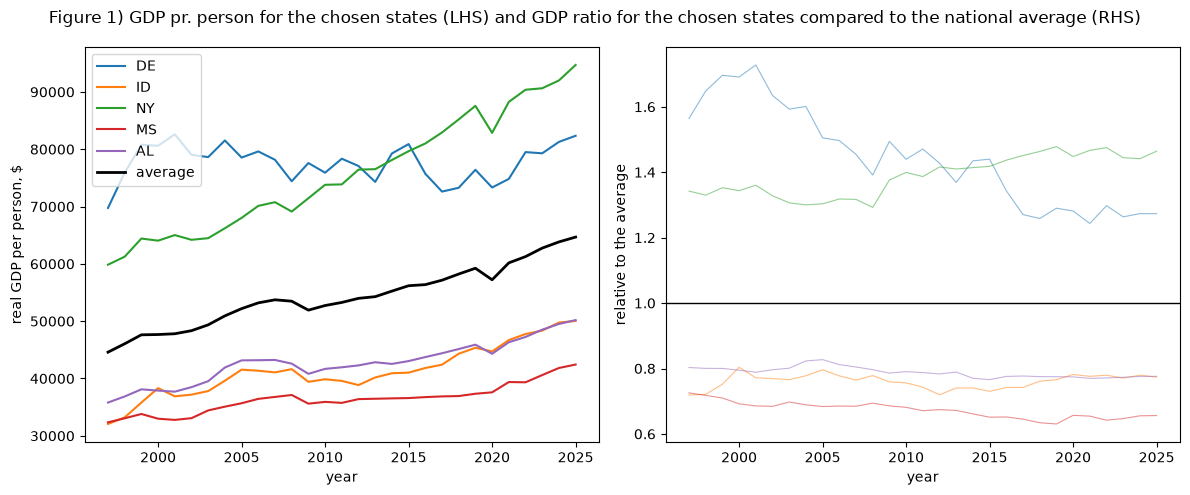

In [25]:
import matplotlib.pyplot as plt

# a. Specifying the states 
some_states = ['DE','ID','NY','MS','AL'] 

# b. yearly averages
avg = y.mean(axis=1)        

# c. GDP pr person divided by the yearly average across all states in that year
ratio = y.divide(avg, axis=0)                            

# d. specifying the plot
fig = plt.figure(figsize=(12,5))

# i. averages for the specified states
ax1 = fig.add_subplot(1,2,1)
for state in some_states:
    ax1.plot(y.index, y[state], label=state)
ax1.plot(y.index, avg, color='black', lw=2, label='average')
ax1.set_xlabel('year')
ax1.set_ylabel('real GDP per person, $')
ax1.legend(loc='upper left')

# ii: the specified states relative to the average across all states
ax2 = fig.add_subplot(1,2,2)
for state in some_states:
    ax2.plot(ratio.index, ratio[state], lw=0.8, alpha=0.5)
ax2.axhline(1, color='black', lw=1)                    
ax2.set_xlabel('year')
ax2.set_ylabel('relative to the average')

fig.suptitle("Figure 1) GDP pr. person for the chosen states (LHS) and GDP ratio for the chosen states compared to the national average (RHS)")
fig.tight_layout()

We have read this question as the second plot to only account for the handful of states as in the first plot. Here we chose the four that we found in question 1.1.4. plus Alabama. 

From panel 1, we see that all states display a clear growth in GDP pr. person. New York and Idaho has the highest growth, whereas Misssisipi and Alabama display growthpatterns that are more in line with the national average. The levels are however different. Delaware has the most fluctuating growth of them all. 

Looking at panel 2, we see how the states perform relative to the average across states, where a value of 1 represents the average. Delaware is clearly above the average throughout the period, but its relative position decreases over time. New York moves further above the average and ends at around 1.45. Idaho and Alabama remain stable at around 0.8 of the average, while Mississippi stays at the lowest level and falls slightly further behind. Overall, the figure shows that the relative development differs quite a lot across the chosen states.

